In [1]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [2]:
from google.colab import files
uploaded = files.upload()  # select DL_Assignment1_Dataset.zip


Saving DL_Assignment1_Dataset.zip to DL_Assignment1_Dataset.zip


In [5]:
# Unzip into the current working directory
!unzip -q DL_Assignment1_Datasetfast.zip -d .

unzip:  cannot find or open DL_Assignment1_Datasetfast.zip, DL_Assignment1_Datasetfast.zip.zip or DL_Assignment1_Datasetfast.zip.ZIP.


Num GPUs Available: 1
📂 Please upload DL_Assignment1_Dataset.zip


Saving DL_Assignment1_Dataset.zip to DL_Assignment1_Dataset.zip
Extracted folders: ['Dataset']
Image dir: Dataset/Dataset/Dataset/images
Annotation dir: Dataset/Dataset/Dataset/annotations
Found images: 3999
Loaded dataset: (3999, 128, 128, 3) (3999,) (3999, 2)
Train: (3199, 128, 128, 3) (3199,) (3199, 2)
Val: (800, 128, 128, 3) (800,) (800, 2)


/tmp/ipython-input-2996504224.py:104: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights="imagenet", include_top=False, input_tensor=inputs)


Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - expr_accuracy: 0.1332 - expr_loss: 2.6171 - loss: 2.9003 - va_loss: 0.5664 - val_expr_accuracy: 0.2262 - val_expr_loss: 2.0142 - val_loss: 2.1804 - val_va_loss: 0.3324
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - expr_accuracy: 0.2290 - expr_loss: 2.0447 - loss: 2.2321 - va_loss: 0.3748 - val_expr_accuracy: 0.2475 - val_expr_loss: 1.9553 - val_loss: 2.0939 - val_va_loss: 0.2773
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - expr_accuracy: 0.2761 - expr_loss: 1.9145 - loss: 2.0674 - va_loss: 0.3058 - val_expr_accuracy: 0.2512 - val_expr_loss: 1.9232 - val_loss: 2.0505 - val_va_loss: 0.2546
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - expr_accuracy: 0.2883 - expr_loss: 1.8658 - loss: 2.0082 - va_loss: 0.2847 - val_expr_accuracy: 0.2688 - val_expr_loss: 1.8956 - val_loss: 2.0177 - val_va_loss: 0.2442
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - expr_accuracy: 0.3250 - expr_loss: 1.7976 - loss: 1.9306

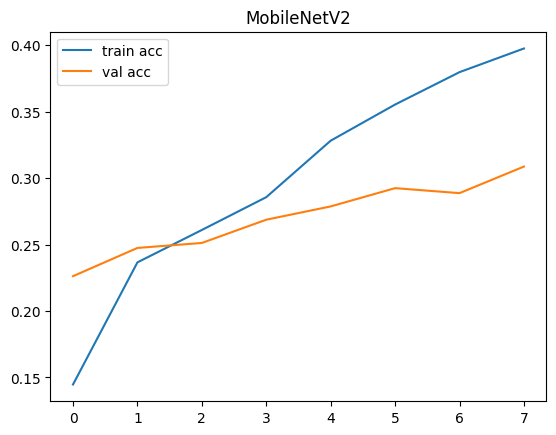

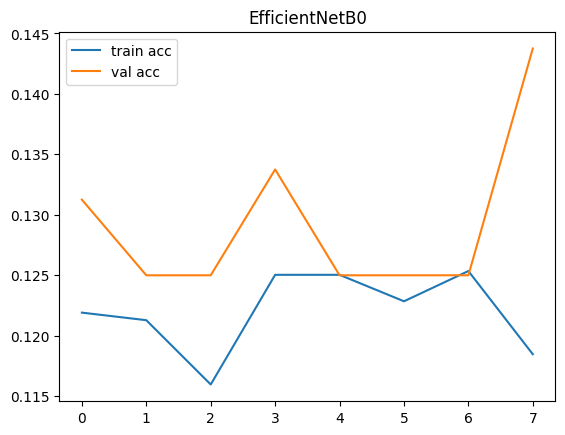

In [3]:
# =========================
# Deep Learning Assignment 1
# Facial Expression + Valence/Arousal
# Baselines: MobileNetV2 & EfficientNetB0
# =========================

# 1) Imports
import os, zipfile
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
from scipy.stats import pearsonr
from google.colab import files

# Check GPU
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# =========================
# 2) Upload and Extract Dataset
# =========================
print("📂 Please upload DL_Assignment1_Dataset.zip")
uploaded = files.upload()  # Upload zip manually

zip_path = [k for k in uploaded.keys()][0]
extract_path = "Dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted folders:", os.listdir(extract_path))

# =========================
# 3) Dataset Paths
# =========================
ROOT = Path("Dataset/Dataset/Dataset")
IMG_DIR = ROOT / "images"
ANN_DIR = ROOT / "annotations"

print("Image dir:", IMG_DIR)
print("Annotation dir:", ANN_DIR)

# =========================
# 4) Load Dataset
# =========================
IMG_SIZE = (128, 128)   # smaller image for faster training

X, y_expr, y_va = [], [], []

all_imgs = [p.stem for p in IMG_DIR.glob("*.jpg")]
print("Found images:", len(all_imgs))

for sid in all_imgs:
    img_path = IMG_DIR / f"{sid}.jpg"
    exp_path = ANN_DIR / f"{sid}_exp.npy"
    val_path = ANN_DIR / f"{sid}_val.npy"
    aro_path = ANN_DIR / f"{sid}_aro.npy"

    if not (exp_path.exists() and val_path.exists() and aro_path.exists()):
        continue

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0

    exp = np.load(exp_path).item()
    val = np.load(val_path).item()
    aro = np.load(aro_path).item()

    X.append(img)
    y_expr.append(exp)
    y_va.append([val, aro])

X = np.array(X)
y_expr = np.array(y_expr, dtype=np.int32)
y_va = np.array(y_va, dtype=np.float32)

print("Loaded dataset:", X.shape, y_expr.shape, y_va.shape)

# =========================
# 5) Train / Validation Split
# =========================
SEED = 42
X_train, X_val, y_train_expr, y_val_expr, y_train_va, y_val_va = train_test_split(
    X, y_expr, y_va, test_size=0.2, random_state=SEED, stratify=y_expr
)

print("Train:", X_train.shape, y_train_expr.shape, y_train_va.shape)
print("Val:", X_val.shape, y_val_expr.shape, y_val_va.shape)

# =========================
# 6) Model Builder
# =========================
def build_multitask_model(backbone="mobilenet", freeze=True):
    inputs = layers.Input(shape=(*IMG_SIZE,3))

    if backbone == "mobilenet":
        base = MobileNetV2(weights="imagenet", include_top=False, input_tensor=inputs)
    elif backbone == "efficientnet":
        base = EfficientNetB0(weights="imagenet", include_top=False, input_tensor=inputs)
    else:
        raise ValueError("Unsupported backbone")

    if freeze:
        base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    expr_out = layers.Dense(8, activation="softmax", name="expr")(x)
    va_out   = layers.Dense(2, activation="tanh", name="va")(x)

    model = models.Model(inputs, [expr_out, va_out])
    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss={"expr": losses.SparseCategoricalCrossentropy(),
              "va": losses.MeanSquaredError()},
        loss_weights={"expr": 1.0, "va": 0.5},
        metrics={"expr": ["accuracy"]}
    )
    return model

# =========================
# 7) Train Baselines
# =========================
def train_baseline(backbone, epochs=3):  # 3 epochs for fast run
    model = build_multitask_model(backbone)
    history = model.fit(
        X_train,
        {"expr": y_train_expr, "va": y_train_va},
        validation_data=(X_val, {"expr": y_val_expr, "va": y_val_va}),
        batch_size=32,
        epochs=epochs
    )
    return model, history

mobilenet_model, mobilenet_history = train_baseline("mobilenet", epochs=8)
efficientnet_model, efficientnet_history = train_baseline("efficientnet", epochs=8)

# =========================
# 8) Metrics
# =========================
def RMSE(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))
def pearson_corr(y_true, y_pred): return np.array([pearsonr(y_true[:,d], y_pred[:,d])[0] for d in range(y_true.shape[1])])
def SAGR(y_true, y_pred): return np.mean(np.sign(y_true) == np.sign(y_pred), axis=0)
def CCC(y_true, y_pred):
    out = []
    for d in range(y_true.shape[1]):
        t, p = y_true[:,d], y_pred[:,d]
        mean_t, mean_p = np.mean(t), np.mean(p)
        var_t, var_p = np.var(t), np.var(p)
        cov = np.mean((t-mean_t)*(p-mean_p))
        out.append((2*cov) / (var_t+var_p+(mean_t-mean_p)**2))
    return np.array(out)

def evaluate_model(model, X, y_expr, y_va):
    pred_expr, pred_va = model.predict(X, batch_size=32)
    y_pred = np.argmax(pred_expr, axis=1)

    acc = accuracy_score(y_expr, y_pred)
    f1  = f1_score(y_expr, y_pred, average="macro")
    kappa = cohen_kappa_score(y_expr, y_pred)

    y_true_bin = np.zeros_like(pred_expr)
    for i,l in enumerate(y_expr): y_true_bin[i,l]=1
    auc_macro = roc_auc_score(y_true_bin, pred_expr, multi_class="ovr")
    ap_macro  = average_precision_score(y_true_bin, pred_expr, average="macro")

    cls_metrics = {"acc":acc,"f1":f1,"kappa":kappa,"auc":auc_macro,"ap":ap_macro}
    reg_metrics = {
        "rmse": RMSE(y_va, pred_va),
        "corr": pearson_corr(y_va, pred_va),
        "sagr": SAGR(y_va, pred_va),
        "ccc":  CCC(y_va, pred_va)
    }
    return cls_metrics, reg_metrics

mobilenet_cls, mobilenet_reg = evaluate_model(mobilenet_model, X_val, y_val_expr, y_val_va)
efficientnet_cls, efficientnet_reg = evaluate_model(efficientnet_model, X_val, y_val_expr, y_val_va)

print("MobileNetV2 Classification:", mobilenet_cls)
print("MobileNetV2 Regression:", mobilenet_reg)
print("EfficientNetB0 Classification:", efficientnet_cls)
print("EfficientNetB0 Regression:", efficientnet_reg)

# =========================
# 9) Training Curves
# =========================
def plot_history(hist, title):
    plt.plot(hist.history["expr_accuracy"], label="train acc")
    plt.plot(hist.history["val_expr_accuracy"], label="val acc")
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(mobilenet_history, "MobileNetV2")
plot_history(efficientnet_history, "EfficientNetB0")


In [5]:
import pandas as pd

# Put results into a dictionary
results = {
    "Model": ["MobileNetV2", "EfficientNetB0"],
    "Accuracy": [0.30875, 0.14375],
    "F1": [0.29795, 0.05855],
    "Kappa": [0.21, 0.021],
    "AUC": [0.709, 0.533],
    "AP": [0.285, 0.137],
    "RMSE": ["[0.520, 0.439]", "[0.467, 0.385]"],
    "Correlation": ["[0.189, 0.156]", "[0.001, 0.026]"],
    "SAGR": ["[0.658, 0.744]", "[0.694, 0.776]"],
    "CCC": ["[0.177, 0.144]", "[0.000, 0.000]"]
}

# Save to CSV
df = pd.DataFrame(results)
df.to_csv("results.csv", index=False)
